In [20]:
import pandas as pd

df = pd.read_csv("q3_retail_promotions.csv")

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [21]:
df = df.sort_values(by= 'transaction_date')

split_index =  int(len(df) * 0.8)

train =  df.iloc[:split_index]
test =  df.iloc[split_index:]

X_train =  train.drop('items_sold', axis=1)
y_train =  train['items_sold']

X_test =  test.drop('items_sold', axis=1)
y_test =  test['items_sold']

We should not use random split because this is a time-based data and the future data should not be used to predict past and random split causes data leakage.

In [22]:
categorical_cols =  ['promotion_type', 'location_type', 'store_size']
numerical_cols = ['year', 'month', 'day_of_week', 'is_weekend', 'is_festival', 'competition_density']

In [23]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor =  ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [24]:
from sklearn.linear_model import LinearRegression

lr_pipeline =  Pipeline(steps= [
    ('preprcessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf =  rf_pipeline.predict(X_test)

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_lr =  np.sqrt(mean_squared_error(y_test,y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression -> RMSE:", rmse_lr, "MAE:", mae_lr)
print("Random Forest -> RMSE:", rmse_rf, "MAE:", mae_rf)

Linear Regression -> RMSE: 27.118892737895045 MAE: 21.064203437451464
Random Forest -> RMSE: 31.33029452192672 MAE: 25.012127083333333


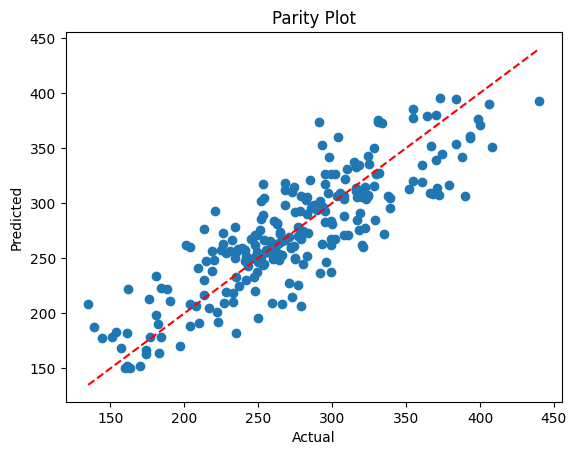

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.title("Parity Plot")
plt.show()

In [28]:
ohe_features =  rf_pipeline.named_steps['preprocessor'] \
      .named_transformers_['cat'] \
      .get_feature_names_out(categorical_cols)

all_features = list(ohe_features) + numerical_cols

importances =  rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(5))

                feature  importance
15          is_festival    0.173527
10     store_size_small    0.168590
7   location_type_urban    0.109480
13          day_of_week    0.096947
16  competition_density    0.066007
